In [1]:
import pandas as pd

df = pd.read_csv('diabetes.csv')

In [2]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

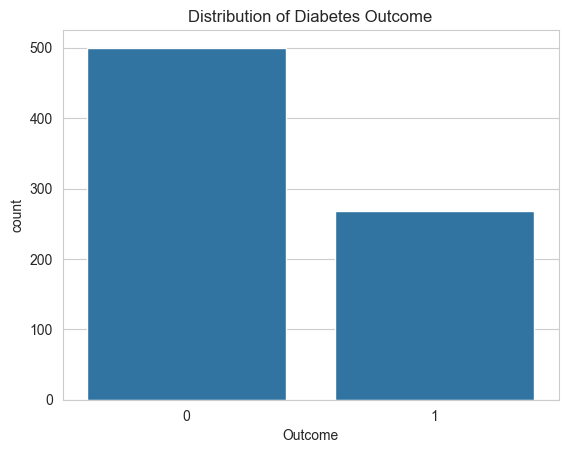

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
ax = sns.countplot(x='Outcome', data=df)
ax.set_title('Distribution of Diabetes Outcome')
plt.show()

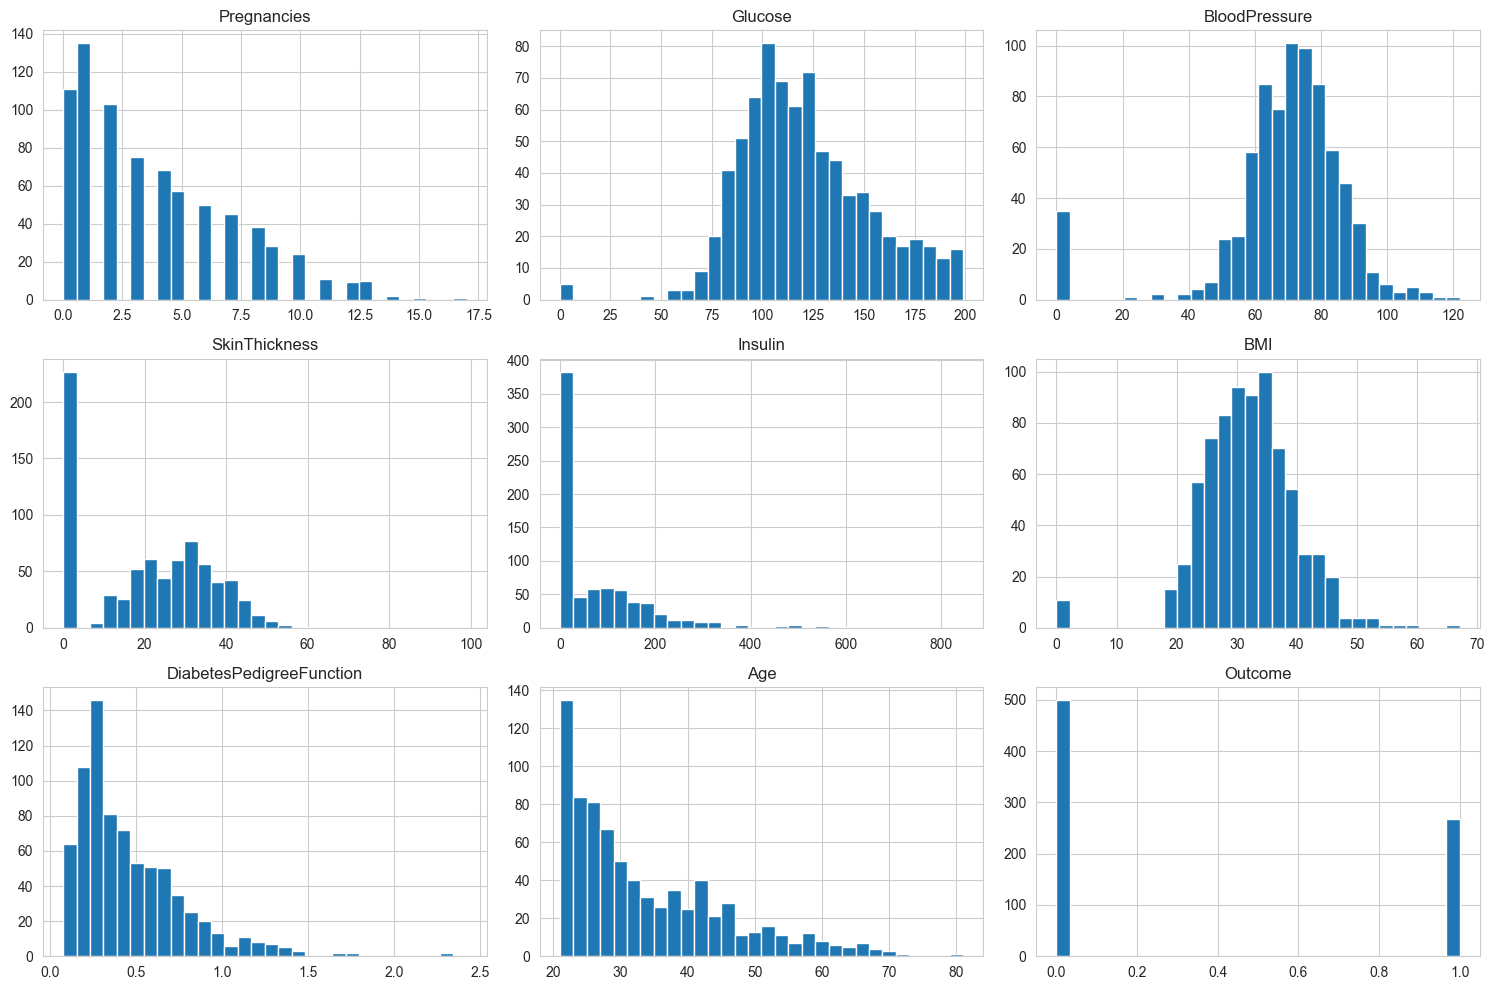

In [8]:
df.hist(figsize=(15, 10), bins=30, layout=(3, 3))

plt.tight_layout()
plt.show()

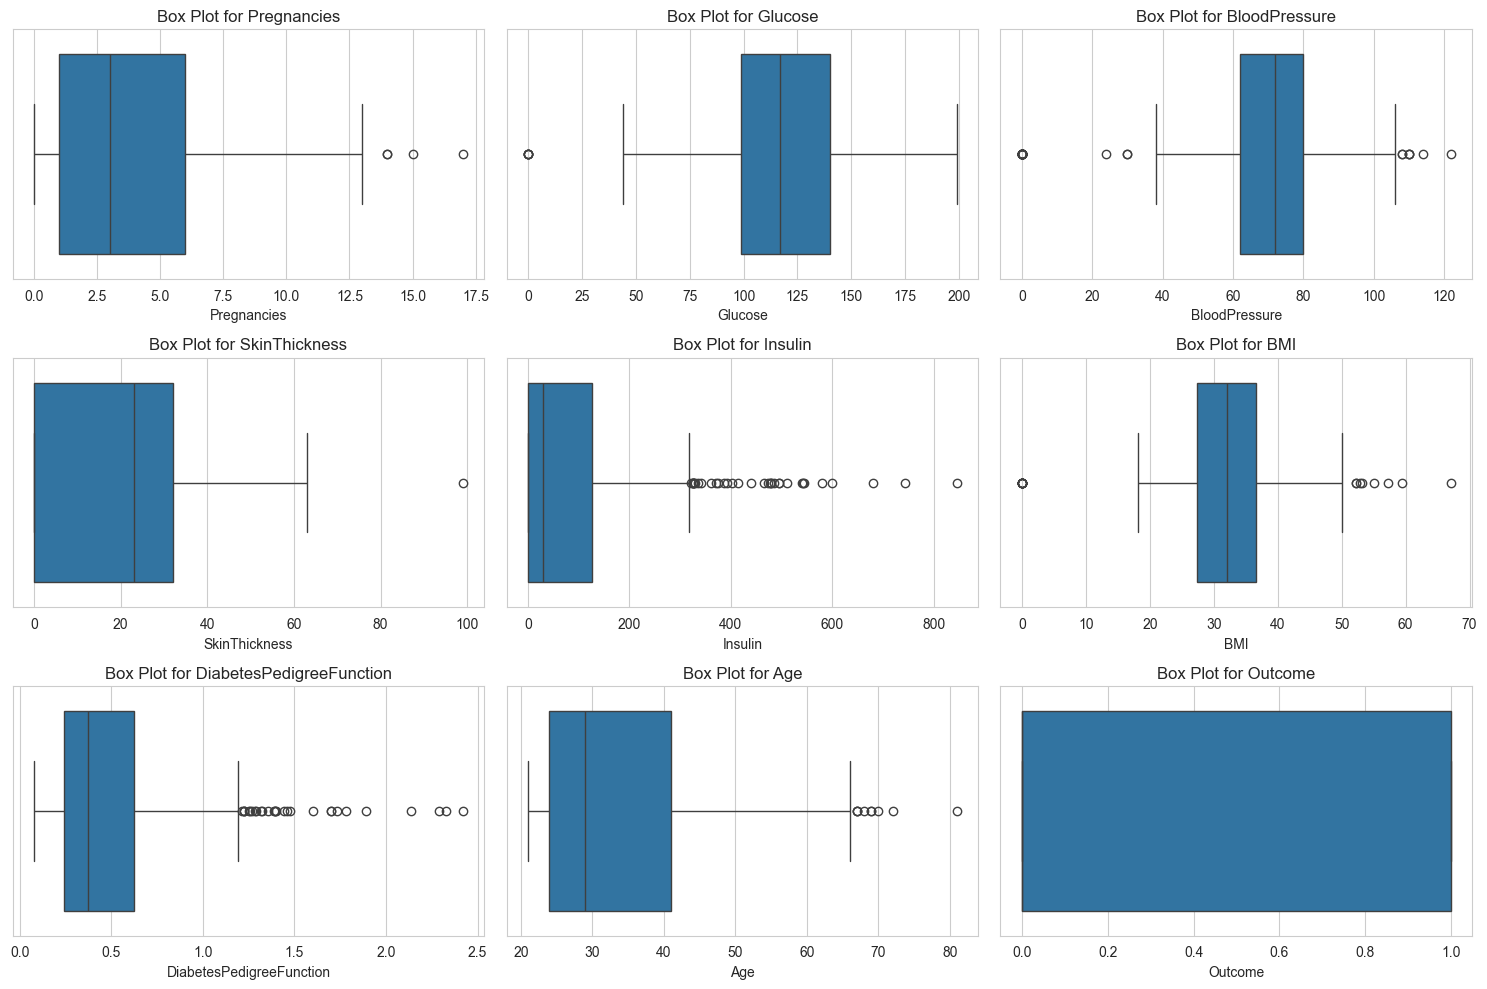

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(x=col, data=df, ax=ax)
    ax.set_title(f'Box Plot for {col}')
    
plt.tight_layout()
plt.show()

In [10]:
correlation_matrix = df.corr()

correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


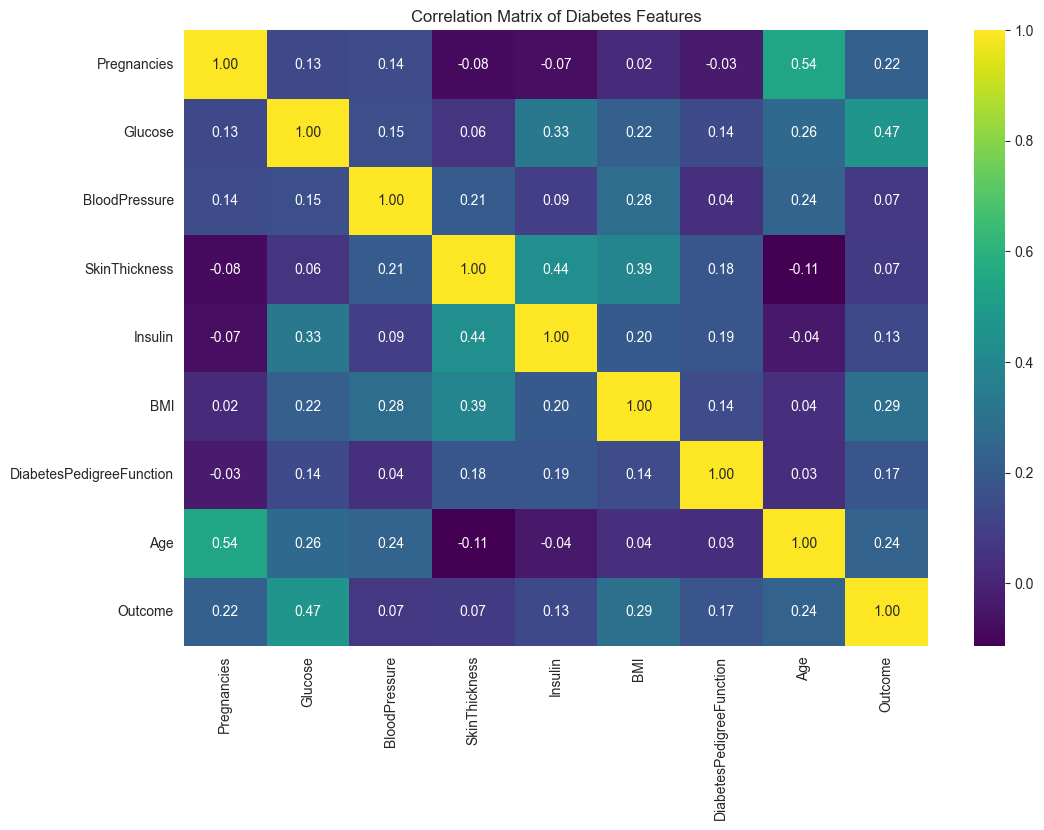

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Diabetes Features')
plt.show()

In [12]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("A peek at the data in the identified columns:")
df[columns_with_zeros].head()

A peek at the data in the identified columns:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148,72,35,0,33.6
1,85,66,29,0,26.6
2,183,64,0,0,23.3
3,89,66,23,94,28.1
4,137,40,35,168,43.1


In [13]:
import numpy as np

df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

print("Data after replacing 0s with NaN:")
df[columns_with_zeros].head()

Data after replacing 0s with NaN:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,NaN,33.6
1,85.0,66.0,29.0,NaN,26.6
2,183.0,64.0,NaN,NaN,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1


In [14]:
missing_values_count = df.isnull().sum()

print("Count of missing values in each column after cleaning:")
print(missing_values_count)

Count of missing values in each column after cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputed_data_array = imputer.fit_transform(df)
df_imputed = pd.DataFrame(imputed_data_array, columns=df.columns)

print("Missing values after imputation:")
print(df_imputed.isnull().sum())
print("\nData after imputation:")
print(df_imputed.head())

df = df_imputed

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data after imputation:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0      1.0  
1                     0.351  31.0      0.0  
2                     0.672  32.0      1.0  
3                     0.167  21.0      0.0  
4 

In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("First 5 rows of our features (X):")
print(X.head())

print("\nFirst 5 rows of our target (y):")
print(y.head())

print(f"\nShape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

First 5 rows of our features (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  
0                     0.627  50.0  
1                     0.351  31.0  
2                     0.672  32.0  
3                     0.167  21.0  
4                     2.288  33.0  

First 5 rows of our target (y):
0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Outcome, dtype: float64

Shape of X: (768, 8)
Shape of y: (768,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of original X:", X.shape)
print("Shape of original y:", y.shape)
print("-" * 30)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("-" * 30)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of original X: (768, 8)
Shape of original y: (768,)
------------------------------
Shape of X_train: (614, 8)
Shape of y_train: (614,)
------------------------------
Shape of X_test: (154, 8)
Shape of y_test: (154,)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("StandardScaler object created successfully:")
print(scaler)

StandardScaler object created successfully:
StandardScaler()


In [19]:
from sklearn.linear_model import LogisticRegression

print("LogisticRegression class imported successfully.")

LogisticRegression class imported successfully.


In [20]:
log_reg = LogisticRegression(random_state=42)

print("Logistic Regression model initialized successfully:")
print(log_reg)

Logistic Regression model initialized successfully:
LogisticRegression(random_state=42)


In [23]:
log_reg.fit(X_train, y_train)

print("Logistic Regression model has been successfully trained (fitted).")
print(log_reg)

Logistic Regression model has been successfully trained (fitted).
LogisticRegression(random_state=42)


C:\Users\manoj\OneDrive\Desktop\Diabetes ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.neighbors import KNeighborsClassifier

print("KNeighborsClassifier class imported successfully.")

KNeighborsClassifier class imported successfully.


In [25]:
knn = KNeighborsClassifier(n_neighbors=5)

print("K-Nearest Neighbors model initialized successfully:")
print(knn)

K-Nearest Neighbors model initialized successfully:
KNeighborsClassifier()


In [27]:
knn.fit(X_train, y_train)

print("K-Nearest Neighbors model has been successfully trained (fitted).")
print(knn)

K-Nearest Neighbors model has been successfully trained (fitted).
KNeighborsClassifier()


In [29]:
y_pred_log_reg = log_reg.predict(X_test)

print("First 20 predictions from the Logistic Regression model:")
print(y_pred_log_reg[:20])

print("\nFirst 20 true labels (y_test):")
print(y_test[:20].values)
print(f"\nShape of predictions array (y_pred_log_reg): {y_pred_log_reg.shape}")
print(f"Shape of true labels array (y_test): {y_test.shape}")

First 20 predictions from the Logistic Regression model:
[1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]

First 20 true labels (y_test):
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]

Shape of predictions array (y_pred_log_reg): (154,)
Shape of true labels array (y_test): (154,)


--- Logistic Regression Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.77      0.82      0.79       100
    Diabetic (1)       0.62      0.54      0.57        54

        accuracy                           0.72       154
       macro avg       0.69      0.68      0.68       154
    weighted avg       0.71      0.72      0.72       154

\n--- Logistic Regression Confusion Matrix ---


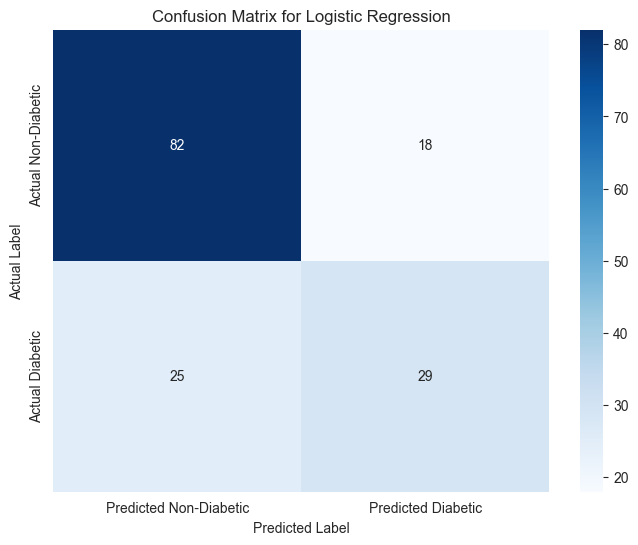

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\\n--- Logistic Regression Confusion Matrix ---")

cm = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,      
            fmt='d',        
            cmap='Blues',   
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


In [32]:
y_pred_knn = knn.predict(X_test)

print("First 20 predictions from the k-NN model:")
print(y_pred_knn[:20])

print("\nFirst 20 true labels (y_test):")
print(y_test[:20].values) 

print(f"\nShape of k-NN predictions array (y_pred_knn): {y_pred_knn.shape}")
print(f"Shape of true labels array (y_test): {y_test.shape}")

First 20 predictions from the k-NN model:
[1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0.]

First 20 true labels (y_test):
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]

Shape of k-NN predictions array (y_pred_knn): (154,)
Shape of true labels array (y_test): (154,)


--- K-Nearest Neighbors (k-NN) Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.74      0.77      0.75       100
    Diabetic (1)       0.54      0.50      0.52        54

        accuracy                           0.68       154
       macro avg       0.64      0.64      0.64       154
    weighted avg       0.67      0.68      0.67       154


--- K-Nearest Neighbors (k-NN) Confusion Matrix ---


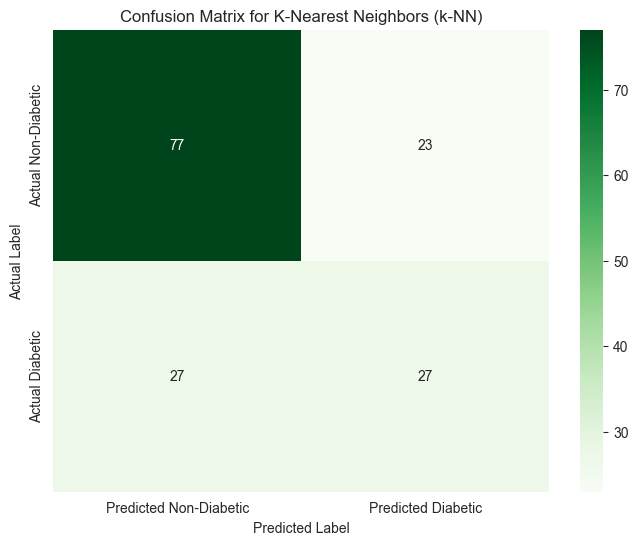

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- K-Nearest Neighbors (k-NN) Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\n--- K-Nearest Neighbors (k-NN) Confusion Matrix ---")

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, 
            annot=True, 
            fmt='d', 
            cmap='Greens', 
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for K-Nearest Neighbors (k-NN)')
plt.show()

In [35]:
from sklearn.metrics import classification_report

report_log_reg = classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)

report_knn = classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)

f1_log_reg = report_log_reg['Diabetic (1)']['f1-score']
f1_knn = report_knn['Diabetic (1)']['f1-score']

print(f"--- F1-Score Comparison ---")
print(f"Logistic Regression F1-Score (Diabetic Class): {f1_log_reg:.4f}")
print(f"K-Nearest Neighbors F1-Score (Diabetic Class): {f1_knn:.4f}")

print("\n--- Initial Conclusion ---")
if f1_log_reg > f1_knn:
    print("Based on the F1-Score, the Logistic Regression model is the initial best performer.")
elif f1_knn > f1_log_reg:
    print("Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.")
else:
    print("Based on the F1-Score, both models have nearly identical performance.")

--- F1-Score Comparison ---
Logistic Regression F1-Score (Diabetic Class): 0.5743
K-Nearest Neighbors F1-Score (Diabetic Class): 0.5192

--- Initial Conclusion ---
Based on the F1-Score, the Logistic Regression model is the initial best performer.


In [37]:
tn_log_reg = cm[0, 0]
fp_log_reg = cm[0, 1]
fn_log_reg = cm[1, 0]
tp_log_reg = cm[1, 1]

tn_knn = cm_knn[0, 0]
fp_knn = cm_knn[0, 1]
fn_knn = cm_knn[1, 0]
tp_knn = cm_knn[1, 1]

print("--- Error Analysis: Logistic Regression vs. k-NN ---")
print("\n--- Logistic Regression ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_log_reg}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_log_reg}  <-- MOST CRITICAL ERROR")

print("\n--- K-Nearest Neighbors ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_knn}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_knn}  <-- MOST CRITICAL ERROR")

print("\n--- Final Conclusion ---")
if fn_log_reg < fn_knn:
    print(f"The Logistic Regression model is the superior baseline.")
    print(f"It produced {fn_knn - fn_log_reg} fewer False Negatives, which is our primary concern.")
elif fn_knn < fn_log_reg:
    print(f"The K-Nearest Neighbors model is the superior baseline.")
    print(f"It produced {fn_log_reg - fn_knn} fewer False Negatives, which is our primary concern.")
else:
    print("Both models produced the same number of False Negatives.")
    print("We can fall back to the F1-score to make our final decision.")


--- Error Analysis: Logistic Regression vs. k-NN ---

--- Logistic Regression ---
False Positives (Predicted Diabetic, Was Healthy): 18
False Negatives (Predicted Healthy, Was Diabetic): 25  <-- MOST CRITICAL ERROR

--- K-Nearest Neighbors ---
False Positives (Predicted Diabetic, Was Healthy): 23
False Negatives (Predicted Healthy, Was Diabetic): 27  <-- MOST CRITICAL ERROR

--- Final Conclusion ---
The Logistic Regression model is the superior baseline.
It produced 2 fewer False Negatives, which is our primary concern.
